# English Sign Language Recognition Models Training

This notebook contains the implementation, training, and evaluation of multiple deep learning and computer vision approaches for English Sign Language alphabet recognition, including CNN, MobileNetV2, and MediaPipe-based models.

Import necessary libraries for model training and evaluation.


In [ ]:
import os, random, glob
import numpy as np
!pip install tensorflow # Install the latest compatible version of TensorFlow
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 32.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.20 requires protobuf<5,>=4.25.3, but you have protobuf 7.34.1 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is incompatible.
ope

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import cv2

Connect Google Drive and locate the dataset file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/ENData/asl_alphabet_train.zip"

In [ ]:
import zipfile
import os

extract_path = "/content/asl_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [ ]:
print("Main folders:", os.listdir(extract_path))

Main folders: ['asl_alphabet_train']


['R', 'O', 'U', 'P', 'D']


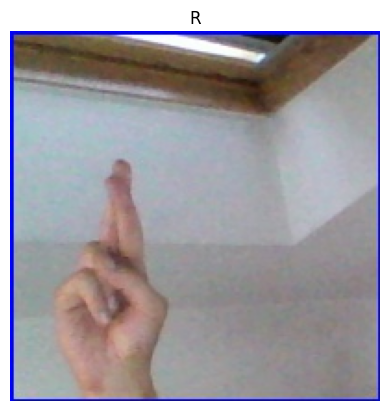

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2


DATA_DIR = "/content/asl_data/asl_alphabet_train"


print(os.listdir(DATA_DIR)[:5])


class_name = os.listdir(DATA_DIR)[0]
img_path = os.path.join(DATA_DIR, class_name, os.listdir(os.path.join(DATA_DIR, class_name))[0])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(class_name)
plt.axis('off')
plt.show()

# Analyze the dataset structure and display the distribution of images across all sign language classes.

In [ ]:
import os


DATA_DIR = "/content/asl_data/asl_alphabet_train"


classes = os.listdir(DATA_DIR)

print("Number of classes:", len(classes))
print("-" * 40)

total_images = 0

for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        total_images += num_images

        print(f"Class: {cls} --> {num_images} images")

print("-" * 40)
print("Total images in dataset:", total_images)

Number of classes: 29
----------------------------------------
Class: E --> 3000 images
Class: O --> 3000 images
Class: V --> 3000 images
Class: X --> 3000 images
Class: J --> 3000 images
Class: H --> 3000 images
Class: W --> 3000 images
Class: S --> 3000 images
Class: space --> 3000 images
Class: G --> 3000 images
Class: L --> 3000 images
Class: Q --> 3000 images
Class: T --> 3000 images
Class: M --> 3000 images
Class: P --> 3000 images
Class: Y --> 3000 images
Class: C --> 3000 images
Class: I --> 3000 images
Class: D --> 3000 images
Class: Z --> 3000 images
Class: R --> 3000 images
Class: A --> 3000 images
Class: B --> 3000 images
Class: K --> 3000 images
Class: N --> 3000 images
Class: U --> 3000 images
Class: del --> 3000 images
Class: F --> 3000 images
Class: nothing --> 3000 images
----------------------------------------
Total images in dataset: 87000


# The first Model **CNN**

Apply image augmentation techniques and prepare training and validation data generators.

In [ ]:
DATA_DIR = "/content/asl_data/asl_alphabet_train"


IMG_HEIGHT, IMG_WIDTH = 64, 64
BATCH_SIZE = 32

# ImageDataGenerator and Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 80% تدريب، 20% اختبار
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


Define the CNN architecture and configure the model for training and classification.

In [ ]:
num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,941 (2.62 MB)

 Trainable params: 686,941 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Training on 5 EPOCHS

In [ ]:
EPOCHS = 5
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 628s 288ms/step - accuracy: 0.3925 - loss: 1.9524 - val_accuracy: 0.5979 - val_loss: 1.3244
Epoch 2/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 693s 293ms/step - accuracy: 0.7088 - loss: 0.8461 - val_accuracy: 0.7211 - val_loss: 0.8735
Epoch 3/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 623s 286ms/step - accuracy: 0.8049 - loss: 0.5627 - val_accuracy: 0.7497 - val_loss: 0.8160
Epoch 4/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 616s 283ms/step - accuracy: 0.8551 - loss: 0.4198 - val_accuracy: 0.7701 - val_loss: 0.7171
Epoch 5/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 618s 284ms/step - accuracy: 0.8856 - loss: 0.3322 - val_accuracy: 0.7769 - val_loss: 0.8040


Test the trained CNN model by predicting the class of a sample sign language image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted class: A


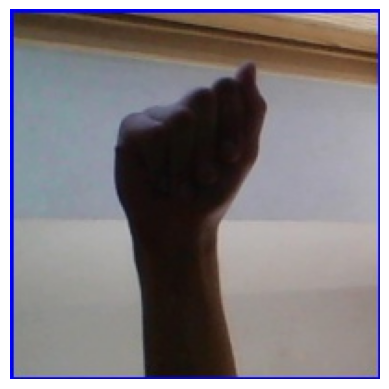

In [ ]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_idx = np.argmax(pred)
    class_labels = list(train_generator.class_indices.keys())

    print("Predicted class:", class_labels[class_idx])
    plt.imshow(cv2.imread(img_path)[:,:,::-1])
    plt.axis('off')
    plt.show()

# تجربة على صورة
sample_img = "/content/asl_data/asl_alphabet_train/A/A1.jpg"  # غيري حسب صورة عندك
predict_image(sample_img)

Real-Time Sign Language Recognition Test

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.body.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [ ]:
def predict_from_camera():
    img_path = take_photo()

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # نفس المعالجة
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img_resized = img_resized / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    pred = model.predict(img_resized)
    class_idx = np.argmax(pred)
    class_labels = list(train_generator.class_indices.keys())

    print("Prediction:", class_labels[class_idx])

    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis('off')
    plt.show()

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediction: A


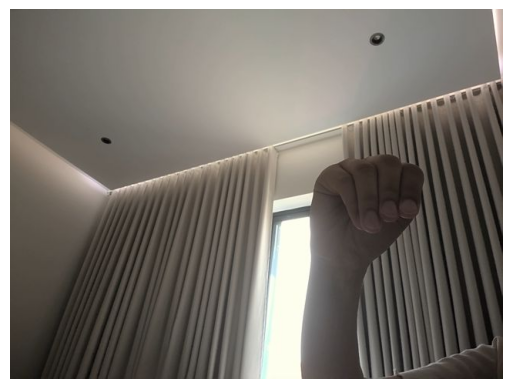

In [ ]:
predict_from_camera()

# The Second model MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

Apply image normalization and data augmentation, then split the dataset into training and validation sets for MobileNetV2 training.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation'
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1162s 525ms/step - accuracy: 0.6799 - loss: 1.0274 - val_accuracy: 0.7549 - val_loss: 0.7817
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1107s 509ms/step - accuracy: 0.8192 - loss: 0.5530 - val_accuracy: 0.7710 - val_loss: 0.7555
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1079s 496ms/step - accuracy: 0.8426 - loss: 0.4686 - val_accuracy: 0.7905 - val_loss: 0.6706
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1085s 499ms/step - accuracy: 0.8548 - loss: 0.4322 - val_accuracy: 0.7856 - val_loss: 0.7002
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1109s 502ms/step - accuracy: 0.8672 - loss: 0.3974 - val_accuracy: 0.7804 - val_loss: 0.7295
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1080s 497ms/step - accuracy: 0.8704 - loss: 0.3877 - val_accuracy: 0.8086 - val_loss: 0.6283
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1164s 535ms/step - accuracy: 0.8771 - loss: 0.3639 - val_accuracy: 0.8013 - val_loss: 0.6316
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1118s 514ms/s

In [ ]:
model.save("/content/drive/MyDrive/mobilenetv2_asl_model.h5")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_generator = datagen.flow_from_directory(
    "/content/asl_data/asl_alphabet_train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    shuffle=False
)

Found 17400 images belonging to 29 classes.


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

loss, accuracy = model.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

544/544 ━━━━━━━━━━━━━━━━━━━━ 54s 73ms/step - accuracy: 0.8409 - loss: 0.5628
Validation Accuracy: 0.8408620953559875


In [ ]:
import numpy as np

predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

544/544 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[562   5   0   0  10   0   0   0   0   0   0   0  17   0   0   0   0   1
    5   0   0   0   0   0   0   0   0   0   0]
 [  2 562   0   0   8   0   0   0  16   0   0   0   0   0   0   0   0   1
    0   0   3   1   7   0   0   0   0   0   0]
 [  0   0 560   0   0   0   0   0   0   0   0   1   0   0  17   0   0   0
    0   0   0   0   0   0   0   0  22   0   0]
 [  0   0   0 542   0   0   0   0   0   0   2   0   0   0  24   0   0  18
    0   0   6   7   0   0   0   1   0   0   0]
 [ 12  27   0   0 499   0   0   0   6   0   0   0   2   6   0   0   0   5
   32   1  10   0   0   0   0   0   0   0   0]
 [  0   0   0   1   0 598   1   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   2   1 531  54   0   9   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   3   0]
 [  0   0   0   0   0   0  36 550   0   4   0   0   0   0   0   0   0   3
    7   0   0   0   0   0   0   0   0   0   0]
 [  0   1   0   0  35   0   0   

In [ ]:
from sklearn.metrics import classification_report

class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       0.91      0.94      0.92       600
           B       0.93      0.94      0.93       600
           C       1.00      0.93      0.96       600
           D       0.95      0.90      0.93       600
           E       0.90      0.83      0.86       600
           F       1.00      1.00      1.00       600
           G       0.87      0.89      0.88       600
           H       0.86      0.92      0.89       600
           I       0.94      0.75      0.84       600
           J       0.85      0.73      0.79       600
           K       0.98      0.91      0.94       600
           L       1.00      0.96      0.98       600
           M       0.83      0.75      0.79       600
           N       0.72      0.87      0.78       600
           O       0.83      0.77      0.80       600
           P       0.97      0.88      0.92       600
           Q       0.98      0.98      0.98       600
           R       0.66    

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: B  Confidence: 0.74


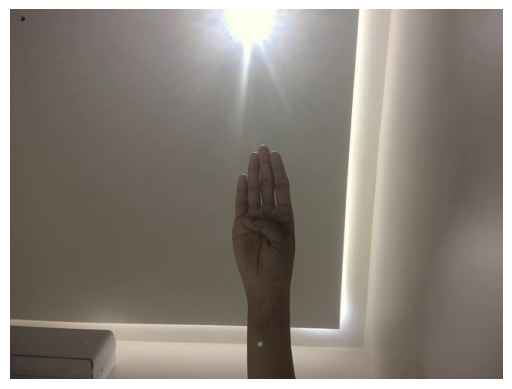

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✨ استخدمي نفس الحجم اللي دربتي عليه
IMG_HEIGHT, IMG_WIDTH = 224, 224

# أسماء الحروف من فولدر التدريب
TRAIN_DIR = "/content/asl_data/asl_alphabet_train"
class_names = sorted(os.listdir(TRAIN_DIR))

# وظيفة لأخذ صورة من الكاميرا في Colab
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.body.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# وظيفة التنبؤ من الصورة الملتقطة
def predict_from_camera():
    img_path = take_photo()

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # معالجة الصورة
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img_resized = img_resized / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    # التنبؤ باستخدام مودلك
    pred = model.predict(img_resized)
    class_idx = np.argmax(pred)

    # عرض النتيجة
    predicted_class = class_names[class_idx]
    confidence = np.max(pred)
    print(f"Prediction: {predicted_class}  Confidence: {confidence:.2f}")

    # عرض الصورة
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# شغلي التنبؤ
predict_from_camera()

# Test

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/mobilenetv2_asl_model.h5")

In [ ]:
import zipfile

zip_path = "/content/archive (5).zip"
extract_path = "/content/asl_test"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("تم فك الضغط ✅")

تم فك الضغط ✅


The external test dataset consisted of 870 images that were not used during model training

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

test_dir = "/content/asl_test/asl-alphabet-test"

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 870 files belonging to 29 classes.


In [ ]:
# 1)
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2)
model = load_model("/content/drive/MyDrive/mobilenetv2_asl_model.h5")

# 3)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
test_dir = "/content/asl_test/asl-alphabet-test"

# 4)
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 5)
test_data = test_data.map(lambda x, y: (x / 255.0, y))

# 6)
predictions = model.predict(test_data)

# 7)
y_pred = np.argmax(predictions, axis=1)

# 8)
y_true = np.concatenate([y for x, y in test_data], axis=0)

# 9)
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Found 870 files belonging to 29 classes.
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step
Accuracy: 0.28620689655172415


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

test_data = test_data.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
predictions = model.predict(test_data)

28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 560ms/step


In [ ]:
import numpy as np

y_pred = np.argmax(predictions, axis=1)

In [ ]:
y_true = np.concatenate([y for x, y in test_data], axis=0)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 0  0  0  0  0  1  0  0  0  0 12  1  0  0  0  0  0  0  0  0  0  1 15  0
   0  0  0  0  0]
 [ 0  4  0  1  1  1  0  0  1  0  6  0  0  0  0  1  0  1  0  0  2  2 10  0
   0  0  0  0  0]
 [ 0  1  3  6  0  1  0  1  0  0 11  1  0  0  0  0  0  0  0  0  0  0  5  0
   0  0  0  0  1]
 [ 0  0  0  9  0  1  0  2  0  0 10  0  0  0  1  0  0  5  0  0  1  0  0  0
   0  0  0  0  1]
 [ 1  3  0  0  6  1  0  2  3  0  9  0  0  1  1  0  0  0  0  0  1  0  2  0
   0  0  0  0  0]
 [ 0  0  0  2  0  2  0  0  0  0 16  1  0  0  0  0  0  1  0  0  0  2  4  0
   2  0  0  0  0]
 [ 0  2  0  0  0  0  1  8  2  0  2  0  0  0  0  0  0  1  0  1  3  1  3  0
   2  4  0  0  0]
 [ 0  0  0  0  0  0  0 18  7  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0
   0  2  1  0  0]
 [ 0  0  0  0  4  0  1  4  5  1  6  1  0  0  0  0  0  1  0  0  6  0  0  0
   1  0  0  0  0]
 [ 0  4  0  0  3  0  1 10  2  1  0  1  0  0  0  0  0  0  0  0  0  1  0  0
   3  4  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0 19  0  0  0  0  0  0  3  0  0  0  6  1  0
   0  



# The text-to-sign translation direction

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = "/content/asl_data/asl_alphabet_train"

In [ ]:
def get_random_image(letter):
    letter = letter.upper()  # نحول لكابيتال

    class_path = os.path.join(DATA_DIR, letter)

    if not os.path.exists(class_path):
        print("الحرف غير موجود ❌")
        return

    images = os.listdir(class_path)

    if len(images) == 0:
        print("مافي صور ❌")
        return

    # اختيار صورة عشوائية
    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # عرض الصورة
    plt.imshow(img)
    plt.title(f"Letter: {letter}")
    plt.axis('off')
    plt.show()

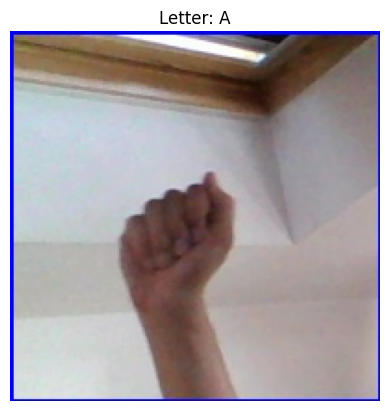

In [ ]:
get_random_image("A")

ادخلي حرف: D


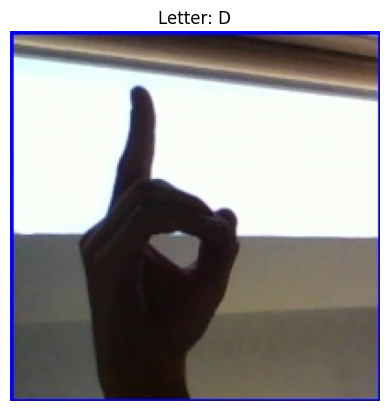

In [ ]:
letter = input("ادخلي حرف: ")
get_random_image(letter)

 Second Real-Time Prediction Evaluation for MobilNetV2 Model


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [ ]:

MODEL_PATH = "/content/drive/MyDrive/mobilenetv2_asl_model.h5"
model = load_model(MODEL_PATH)

print("Model Loaded ✅")

Model Loaded ✅


In [ ]:
class_labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + ["space", "delete", "nothing"]

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const button = document.createElement('button');
            button.textContent = '📸 Capture';
            div.appendChild(button);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [ ]:
import os

folder = DATA_DIR + "/A"
print(os.listdir(folder)[:5])

['A1116.jpg', 'A1285.jpg', 'A2139.jpg', 'A2705.jpg', 'A2809.jpg']


In [ ]:
img_path = DATA_DIR + "/A/" + os.listdir(folder)[0]
print(img_path)

/content/asl_data/asl_alphabet_train/A/A1116.jpg


In [ ]:
class_labels = sorted(os.listdir(DATA_DIR))

print(class_labels)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [ ]:
import cv2
import numpy as np
import os


# 🔥 تعريف الكلاسات
class_labels = sorted(os.listdir(DATA_DIR))

img = cv2.imread(img_path)

if img is None:
    print("❌ الصورة ما انقرت")
else:
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)

    print("Prediction:", class_labels[np.argmax(pred)])
    print("Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Prediction: A
Confidence: 0.99364555


In [ ]:
def preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    return img

In [ ]:
def normalize_light(img):
    return cv2.convertScaleAbs(img, alpha=1.0, beta=0)

In [ ]:
def predict_live():
    img_path = take_photo()
    img = cv2.imread(img_path)

    if img is None:
        print("❌ خطأ في الصورة")
        return

    # 🔥 بدون تخريب
    img = normalize_light(img)

    # 🔥 preprocessing مطابق للتدريب
    img = preprocess(img)

    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)
    class_idx = np.argmax(pred)
    confidence = np.max(pred)

    print("Prediction:", class_labels[class_idx])
    print("Confidence:", confidence)

In [ ]:
predict_live()

<IPython.core.display.Javascript object>

Prediction: B
Confidence: 0.8630655


In [ ]:
while True:
    predict_live()

    cont = input("Continue? (y/n): ")
    if cont.lower() != 'y':
        break

<IPython.core.display.Javascript object>

Prediction: E
Confidence: 0.6908608
Continue? (y/n): y


<IPython.core.display.Javascript object>

Prediction: B
Confidence: 0.999941
Continue? (y/n): y


<IPython.core.display.Javascript object>

...

Prediction: I
Confidence: 0.709985
Continue? (y/n): y


<IPython.core.display.Javascript object>

Prediction: A
Confidence: 0.64283663
Continue? (y/n): y


<IPython.core.display.Javascript object>

Prediction: S
Confidence: 0.7708237
Continue? (y/n): n


# The Third Model **Mediapipe Model + Classifr**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/asl_data/asl_alphabet_train"

In [ ]:
!pip uninstall mediapipe protobuf tensorflow keras -y

Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2


In [ ]:
!pip install protobuf==3.20.3
!pip install mediapipe==0.10.20
!pip install tensorflow==2.13.0

  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-hub 0.26.0 requires keras>=3.13, which is not installed.
mediapipe 0.10.20 requires protobuf<5,>=4.25.3, but you have protobuf 3.20.3 which is incompatible.
google-cloud-speech 2.38.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-translate 3.26.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-trace 1.19.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-resource-mana

  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-hub 0.26.0 requires keras>=3.13, which is not installed.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.


ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.13.0


In [ ]:
import mediapipe as mp

print("MediaPipe:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

MediaPipe: 0.10.20
Has solutions: True


In [ ]:
import cv2
import mediapipe as mp

mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

In [ ]:
import cv2
import os

img_path = "/content/asl_data/asl_alphabet_train/A/A1.jpg"

print(os.path.exists(img_path))

img = cv2.imread(img_path)

print(img is not None)

True
True


In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# تهيئة MediaPipe Hands
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

# المسار الصحيح للصورة
img_path = "/content/asl_data/asl_alphabet_train/A/A1.jpg"

# قراءة الصورة
img = cv2.imread(img_path)

# تحقق من الصورة
if img is None:
    print("❌ الصورة ما انقرت تأكدي من المسار")
else:
    print("✔ الصورة انقرت")

    # تحويل اللون
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # تشغيل MediaPipe
    result = hands.process(img_rgb)

    # استخراج اليد
    if result.multi_hand_landmarks:
        print("✔ Hand detected")

        hand = result.multi_hand_landmarks[0]

        landmarks = []
        for lm in hand.landmark:
            landmarks.extend([lm.x, lm.y, lm.z])

        print("عدد النقاط:", len(landmarks))  # لازم = 63
    else:
        print("❌ No hand detected")

✔ الصورة انقرت
✔ Hand detected
عدد النقاط: 63


In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp

mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

DATA_DIR = "/content/asl_data/asl_alphabet_train"

X = []
y = []

class_names = sorted(os.listdir(DATA_DIR))

SAVE_EVERY = 1000  # 🔥 يحفظ كل فترة

count = 0

for label in class_names:
    folder_path = os.path.join(DATA_DIR, label)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = hands.process(img_rgb)

        if result.multi_hand_landmarks:
            hand = result.multi_hand_landmarks[0]

            landmarks = []
            for lm in hand.landmark:
                landmarks.extend([lm.x, lm.y, lm.z])

            X.append(landmarks)
            y.append(label)

        count += 1

        # 🔥 حفظ تدريجي لتجنب loss
        if count % SAVE_EVERY == 0:
            print("Saved at:", count)

            np.save("/content/X_temp.npy", np.array(X))
            np.save("/content/y_temp.npy", np.array(y))

X = np.array(X)
y = np.array(y)

np.save("/content/X_final.npy", X)
np.save("/content/y_final.npy", y)

print("✔ DONE FULL DATASET")
print("Shape:", X.shape)

Saved at: 1000
Saved at: 2000
Saved at: 3000
Saved at: 4000
Saved at: 5000
Saved at: 6000
Saved at: 7000
Saved at: 8000
Saved at: 9000
Saved at: 10000
Saved at: 11000
Saved at: 12000
Saved at: 13000
Saved at: 14000
Saved at: 15000
Saved at: 16000
Saved at: 17000
Saved at: 18000
Saved at: 19000
Saved at: 20000
Saved at: 21000
Saved at: 22000
Saved at: 23000
Saved at: 24000
Saved at: 25000
Saved at: 26000
Saved at: 27000
Saved at: 28000
Saved at: 29000
Saved at: 30000
Saved at: 31000
Saved at: 32000
Saved at: 33000
Saved at: 34000
Saved at: 35000
Saved at: 36000
Saved at: 37000
Saved at: 38000
Saved at: 39000
Saved at: 40000
Saved at: 41000
Saved at: 42000
Saved at: 43000
Saved at: 44000
Saved at: 45000
Saved at: 46000
Saved at: 47000
Saved at: 48000
Saved at: 49000
Saved at: 50000
Saved at: 51000
Saved at: 52000
Saved at: 53000
Saved at: 54000
Saved at: 55000
Saved at: 56000
Saved at: 57000
Saved at: 58000
Saved at: 59000
Saved at: 60000
Saved at: 61000
Saved at: 62000
Saved at: 63000
S

In [ ]:
def normalize_dataset(X):
    X_new = []
    for lm in X:
        coords = np.array(lm).reshape(21, 3)
        coords[:, 0] = 1 - coords[:, 0]
        X_new.append(coords.flatten())
    return np.array(X_new)

X = np.load("/content/X_final.npy")
y = np.load("/content/y_final.npy")

# 🔥 هنا نعدل البيانات كلها
X = normalize_dataset(X)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(63,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(le.classes_), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64
)

Epoch 1/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8502 - loss: 0.5385 - val_accuracy: 0.8481 - val_loss: 0.5171
Epoch 2/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9403 - loss: 0.2004 - val_accuracy: 0.9717 - val_loss: 0.1149
Epoch 3/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9486 - loss: 0.1714 - val_accuracy: 0.9170 - val_loss: 0.2579
Epoch 4/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9514 - loss: 0.1626 - val_accuracy: 0.9772 - val_loss: 0.0849
Epoch 5/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9555 - loss: 0.1435 - val_accuracy: 0.9284 - val_loss: 0.1936
Epoch 6/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9583 - loss: 0.1388 - val_accuracy: 0.9126 - val_loss: 0.2696
Epoch 7/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9573 - loss: 0.1417 - val_accuracy: 0.8825 - val_loss: 0.3536
Epoch 8/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9590 - loss: 0.1339 - val_accuracy: 0

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Final Accuracy:", acc)

398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9744 - loss: 0.0725
Final Accuracy: 0.9744032621383667


In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [ ]:
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

In [ ]:
def predict_live():
    img_path = take_photo()

    img = cv2.imread(img_path)

    if img is None:
        print("❌ No image")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    result = hands.process(img_rgb)

    if not result.multi_hand_landmarks:
        print("❌ No hand detected")
        return

    hand = result.multi_hand_landmarks[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x, lm.y, lm.z])

    landmarks = np.array(landmarks).reshape(1, -1)

    pred = model.predict(landmarks)

    class_idx = np.argmax(pred)
    confidence = np.max(pred)

    print("🔤 Prediction:", le.inverse_transform([class_idx])[0])
    print("🎯 Confidence:", confidence)

In [ ]:
predict_live()

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
🔤 Prediction: G
🎯 Confidence: 0.99874604


398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1200x1000 with 0 Axes>

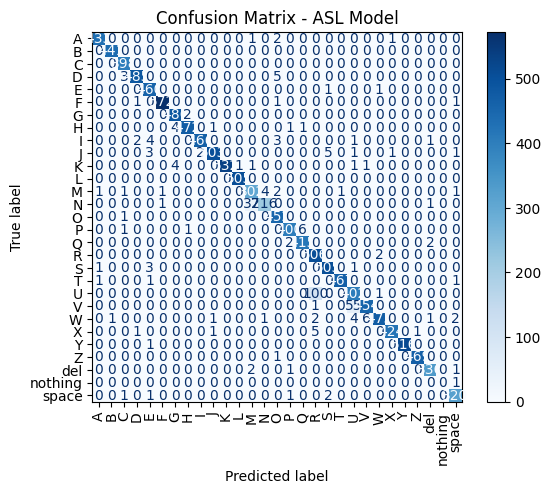

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 🔮 التنبؤ على بيانات الاختبار
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 📊 Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# 🎨 عرضها بشكل جميل
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)

plt.figure(figsize=(12, 10))
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix - ASL Model")
plt.show()

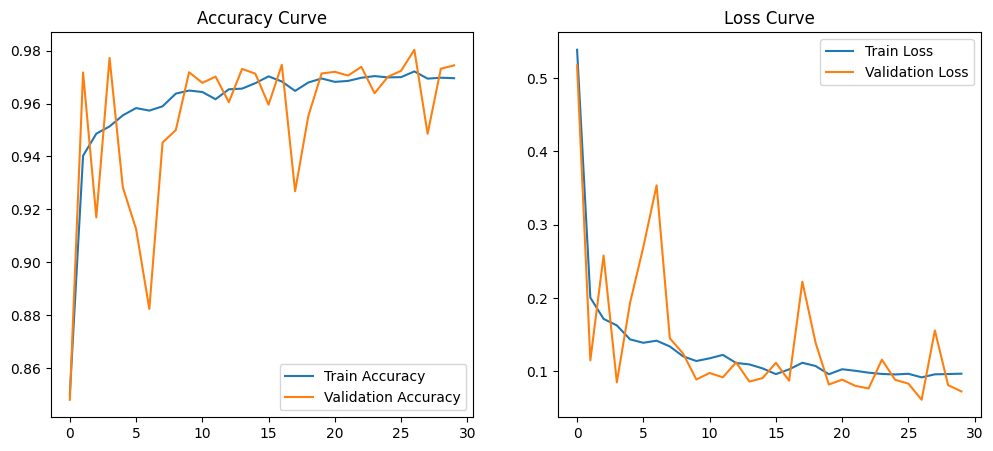

In [ ]:
import matplotlib.pyplot as plt

# تاريخ التدريب (history لازم يكون من model.fit)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# 📊 Accuracy Curve
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# 📉 Loss Curve
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(y_test, y_pred_classes)

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 10:
            print(le.classes_[i], "→", le.classes_[j], cm[i][j])

N → M 37
U → R 100
V → U 55


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

              precision    recall  f1-score   support

           A       0.99      0.99      0.99       437
           B       1.00      1.00      1.00       441
           C       0.98      1.00      0.99       398
           D       0.99      0.98      0.99       493
           E       0.97      1.00      0.98       462
           F       1.00      0.99      1.00       575
           G       0.98      1.00      0.99       488
           H       0.99      0.99      0.99       479
           I       1.00      0.98      0.99       477
           J       0.99      0.97      0.98       516
           K       1.00      0.99      0.99       540
           L       1.00      1.00      1.00       505
           M       0.88      0.96      0.92       313
           N       0.98      0.85      0.91       255
           O       0.97      1.00      0.98       453
           P       0.99      0.98      0.98       408
           Q       0.98      0.99      0.99       419
           R       0.82    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import os
import numpy as np

save_path = "/content/drive/MyDrive/asl_project"

# 🟢 إنشاء المجلد إذا غير موجود
os.makedirs(save_path, exist_ok=True)

np.save(save_path + "/X_landmarks.npy", X)
np.save(save_path + "/y_labels.npy", y)

print("✔ Saved successfully")

✔ Saved successfully


In [ ]:
model.save("/content/drive/MyDrive/asl_project/asl_model2.h5")
print("✔ Model saved")

✔ Model saved


In [ ]:
import pickle

with open("/content/drive/MyDrive/asl_project/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✔ Label encoder saved")

✔ Label encoder saved


In [ ]:
import tensorflow as tf
import shutil

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/asl_project/asl_model2.h5",
    compile=False
)

model.export("/content/drive/MyDrive/english_saved_model")

shutil.make_archive(
    "/content/drive/MyDrive/english_saved_model",
    "zip",
    "/content/drive/MyDrive/english_saved_model"
)

Saved artifact at '/content/drive/MyDrive/english_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 63), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 29), dtype=tf.float32, name=None)
Captures:
  135309379755984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379756560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379758096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379758864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379756176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379757520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379760208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379760976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379761360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135309379762512: TensorSpec(shape=(), dtype=tf.resource, name=Non

'/content/drive/MyDrive/english_saved_model.zip'

# Test on mediapipe model


In [ ]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model("/content/drive/MyDrive/asl_project/asl_model2.h5")

print("✔ Model loaded")

✔ Model loaded


In [ ]:
import tensorflow as tf
import pickle

# model
model = tf.keras.models.load_model("/content/drive/MyDrive/asl_project/asl_model2.h5")

# label encoder
with open("/content/drive/MyDrive/asl_project/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print("✔ Loaded successfully")
print(le.classes_)

✔ Loaded successfully
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'nothing' 'space']


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import os

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True)

TEST_DIR = "/content/asl_test/asl-alphabet-test"

X_test = []
y_test = []

for label in os.listdir(TEST_DIR):
    folder = os.path.join(TEST_DIR, label)

    if not os.path.isdir(folder):
        continue

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = hands.process(img_rgb)

        if result.multi_hand_landmarks:
            lm_list = []
            for lm in result.multi_hand_landmarks[0].landmark:
                lm_list.extend([lm.x, lm.y, lm.z])

            X_test.append(lm_list)
            y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("✔ External test shape:", X_test.shape)

✔ External test shape: (787, 63)


In [ ]:
import numpy as np

# 🔥 نفس normalization اللي استخدمتيه في التدريب
def normalize_dataset(X):
    X_new = []
    for lm in X:
        coords = np.array(lm).reshape(21, 3)

        # نفس فكرة flip (لازم تطابق التدريب)
        coords[:, 0] = 1 - coords[:, 0]

        X_new.append(coords.flatten())

    return np.array(X_new)

# ✔ تطبيق نفس المعالجة
X_test = normalize_dataset(X_test)

print("✔ Test preprocessing done")
print("Shape:", X_test.shape)

✔ Test preprocessing done
Shape: (787, 63)


In [ ]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model("/content/drive/MyDrive/asl_project/asl_model2.h5")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("✔ Prediction done")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
✔ Prediction done


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pickle

# تحميل نفس encoder (المهم جدًا)
with open("/content/drive/MyDrive/asl_project/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

y_test_encoded = le.transform(y_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("✔ External Accuracy:",
      accuracy_score(y_test_encoded, y_pred_classes))

✔ External Accuracy: 0.8831003811944091
